## Notebooks for Exploratory Data Analysis

In this notebook, we will explore the data we get to get a better understanding of the data.

We will be checking for some basic information, distribution and whether there are imbalanced classes, token lengths, whether there are duplicated tweets, and some examples of the data for each stance.

In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# load the dataset
data_path = '../data/Q2_20230202_majority.csv'
df = pd.read_csv(data_path)

### Part 1: Basic Shape and Information

In [3]:
# some basic information about the data
print(f"Rows in the data: {len(df)}\n")
print(f"Column names: {df.columns}\n")
print(f"Data types: {df.dtypes}\n")
print(f"Missing values in the data: {df.isna().sum()}\n")
print("First 5 rows of the data:")
df.head()


Rows in the data: 5751

Column names: Index(['tweet_id', 'created_at', 'tweet', 'label_majority', 'month'], dtype='object')

Data types: tweet_id          float64
created_at         object
tweet              object
label_majority     object
month              object
dtype: object

Missing values in the data: tweet_id          0
created_at        0
tweet             0
label_majority    0
month             0
dtype: int64

First 5 rows of the data:


,tweet_id,created_at,tweet,label_majority,month
0,1.421909e+18,2021-08-01 19:02:51+00:00,"if you in spanish town, st jago park isn't ful...",FAVOR,Aug-21
1,1.421734e+18,2021-08-01 07:26:37+00:00,breaking report: cdc used rejected study from ...,AGAINST,Aug-21
2,1.421889e+18,2021-08-01 17:42:05+00:00,covid clusters among the vaccinated are killin...,AGAINST,Aug-21
3,1.421978e+18,2021-08-01 23:35:28+00:00,so they had an on-site vaccination at work and...,FAVOR,Aug-21
4,1.421798e+18,2021-08-01 11:39:57+00:00,what a dumb bunny. it's a leaky vaccine and y...,AGAINST,Aug-21


There are no missing values in the data.

### 2. Label Distribution and Class Balance Check

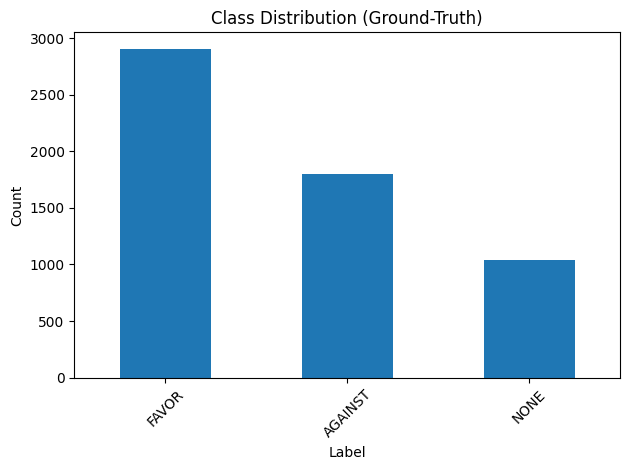

In [4]:
label_counts = df['label_majority'].value_counts()
label_counts.plot(kind='bar', title = "Class Distribution (Ground-Truth)")
plt.xlabel("Label")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 3. Tweet Length Analysis

In [5]:
# length analysis
char_len = df["tweet"].str.len()
token_len = df["tweet"].str.split().str.len()

print("Character length statistics:")
print(char_len.agg(['min', 'max', 'mean', 'median', 'std']).round(2))

print("\nToken length statistics:")
print(token_len.agg(['min', 'max', 'mean', 'median', 'std']).round(2))

Character length statistics:
min         9.00
max       296.00
mean      174.76
median    179.00
std        77.00
Name: tweet, dtype: float64

Token length statistics:
min        1.00
max       60.00
mean      28.81
median    29.00
std       13.12
Name: tweet, dtype: float64


There are no zero length data in the tweets.

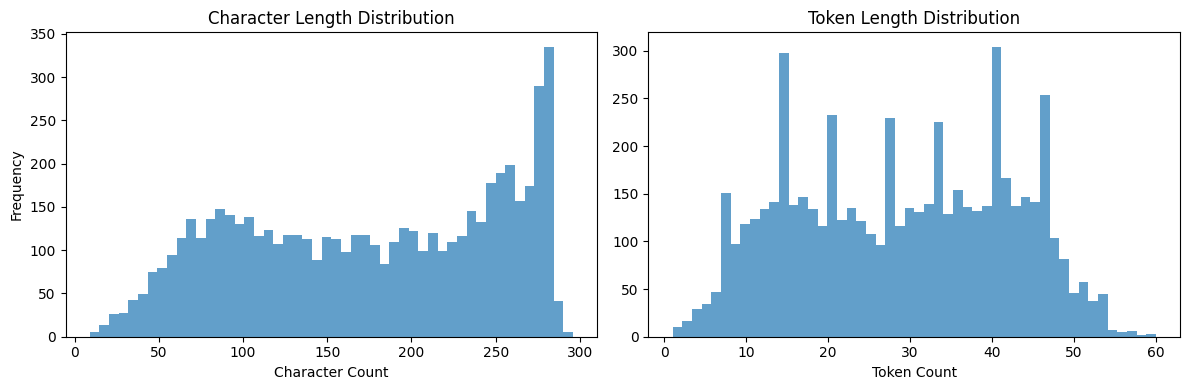

In [6]:
# plot tweet length distribution for both character and token length
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(char_len, bins=50, alpha=0.7)
plt.title('Character Length Distribution')
plt.xlabel('Character Count')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(token_len, bins=50, alpha=0.7)
plt.title('Token Length Distribution')
plt.xlabel('Token Count')
plt.tight_layout()
plt.show()

## 4. Duplication Check

In [7]:
duplicated_tweets = df['tweet'].duplicated()
print("\nExact duplicate tweets:", duplicated_tweets.sum())


Exact duplicate tweets: 73


In [8]:
# check a few examples of the duplicated tweets
duplicated_tweets_df = df[duplicated_tweets]

# for first 5 rows, find their duplicated tweets from data and show them
df_dup_show = pd.DataFrame()
for row in duplicated_tweets_df.head(5).itertuples():
    df_row = df[df['tweet'] == row.tweet]
    df_dup_show = pd.concat([df_dup_show, df_row])

df_dup_show
    

,tweet_id,created_at,tweet,label_majority,month
69,1.423056e+18,2021-08-04 22:57:47+00:00,why y’all buying fake vaccination cards for $5...,FAVOR,Aug-21
97,1.423285e+18,2021-08-05 14:07:27+00:00,why y’all buying fake vaccination cards for $5...,FAVOR,Aug-21
70,1.422732e+18,2021-08-04 01:31:39+00:00,inspirational news from #btsarmy in #indonesia...,FAVOR,Aug-21
117,1.423349e+18,2021-08-05 18:25:17+00:00,inspirational news from #btsarmy in #indonesia...,FAVOR,Aug-21
161,1.424047e+18,2021-08-07 16:35:46+00:00,"average covid hospital stay: $73,300..average ...",FAVOR,Aug-21
172,1.424483e+18,2021-08-08 21:31:03+00:00,"average covid hospital stay: $73,300..average ...",FAVOR,Aug-21
153,1.424144e+18,2021-08-07 23:03:55+00:00,maybe they’re pushing and bribing people to ge...,FAVOR,Aug-21
181,1.424180e+18,2021-08-08 01:23:59+00:00,maybe they’re pushing and bribing people to ge...,FAVOR,Aug-21
269,1.425823e+18,2021-08-12 14:14:44+00:00,i was a vaccine checker tonight at my venue an...,FAVOR,Aug-21
273,1.425802e+18,2021-08-12 12:51:08+00:00,i was a vaccine checker tonight at my venue an...,FAVOR,Aug-21


## 5. Data Examples

In [9]:
# show some examples of the data for each stance
for stance in df['label_majority'].unique():
    print(f"Showing 3 {stance} examples:")
    samples = df[df['label_majority'] == stance]['tweet'].sample(3, random_state=3407)
    for i, tweet in enumerate(samples, 1):
        print(f"{i}. {tweet}")
    print("\n")

Showing 3 FAVOR examples:
1. there have been yellow fever "vaccine passports" for years and years, never heard any civil liberties objections to them. some countries require them for entry, some don't. why shouldn't an international covid vaccine passport eventually function the same way?
2. $100 million for mrna vaccine manufacturing capability in australia? that's one fifth of a war memorial upgrade, and a far better use of the money.
3. are you talking about that same eu that refused to help albania with vaccines?! that same eu of double standards that is not capable keeping it word and so many issues?!.please shut up, and don't give lectures of diplomacy and geopolitics.


Showing 3 AGAINST examples:
1. spot the difference...norway put on a fireworks show and gave people free cake to celebrate removing restrictions. ..australia shot its own citizens with rubber bullets for taking part in "illegal" freedom protests.
2. when people blatantly lie about efficacy of vaccination
3. if yo